<a href="https://colab.research.google.com/github/lambforwork-source/BTAP-NHOM-4-KHDL/blob/main/KHDL_Nh%C3%B3m_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np

# 1. Dùng link RAW chuẩn từ GitHub
url = 'https://raw.githubusercontent.com/lambforwork-source/BTAP-NHOM-4-KHDL/main/adult.csv'

# 2. Đọc dữ liệu và xử lý ngay dấu '?' thành giá trị thiếu (NaN)
df = pd.read_csv(url, na_values='?')

# 3. Kiểm tra xem dữ liệu đã lên chưa
print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


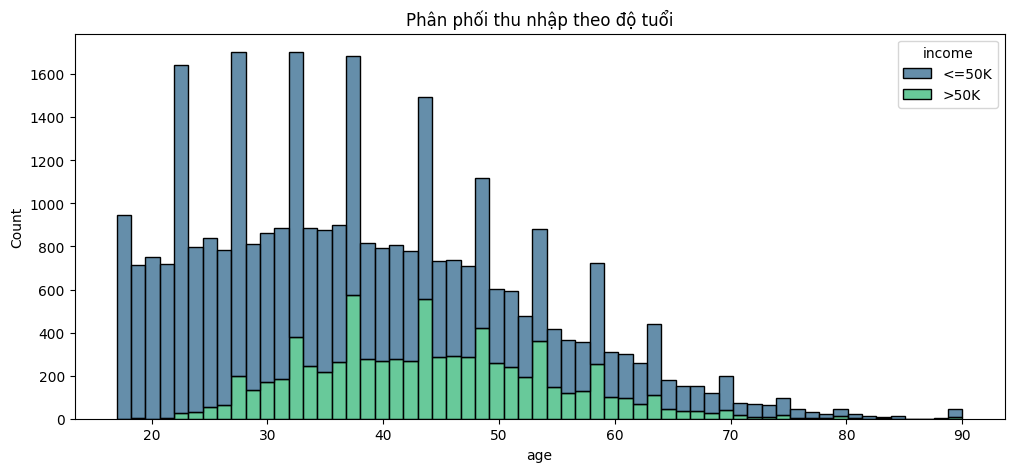

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='age', hue='income', multiple="stack", palette='viridis')
plt.title('Phân phối thu nhập theo độ tuổi')
plt.show()

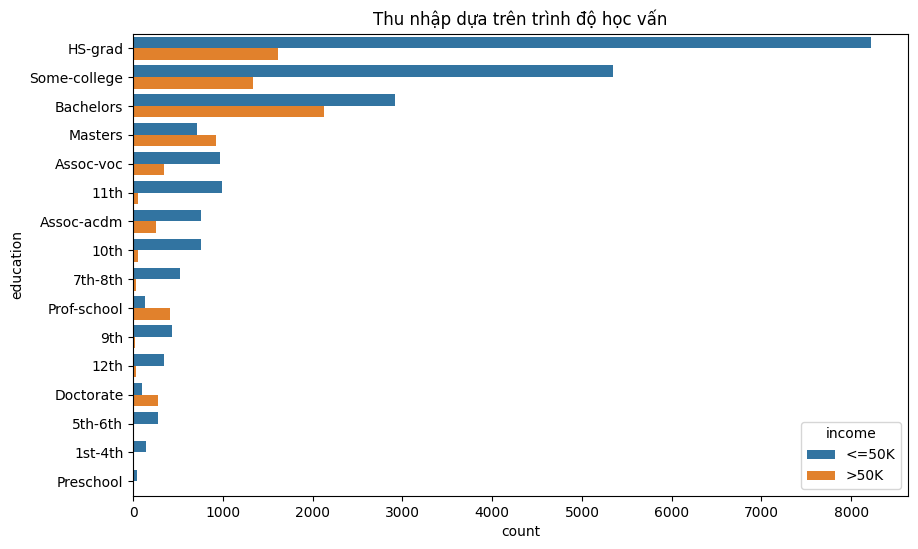

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(y='education', hue='income', data=df, order=df['education'].value_counts().index)
plt.title('Thu nhập dựa trên trình độ học vấn')
plt.show()


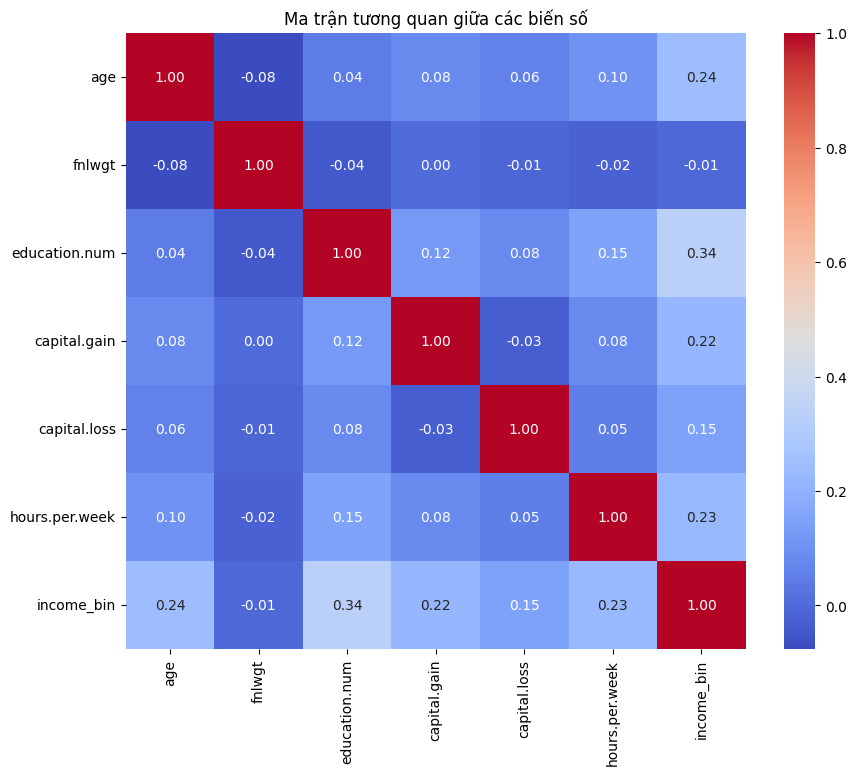

In [19]:
# 1. Hợp nhất các nhóm học vấn (như bạn đã làm)
df['education'] = df['education'].replace(['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th'], 'School')
df['education'] = df['education'].replace(['Assoc-voc', 'Assoc-acdm', 'Prof-school', 'Some-college'], 'Higher-Ed')

# 2. Kiểm tra tương quan - THÊM numeric_only=True để tránh lỗi
plt.figure(figsize=(10, 8))
# Tính toán ma trận tương quan chỉ trên các cột số
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến số')
plt.show()